### this notebook is being written with the intention of postprocessing and generating figures from the outputs of trackastra 070826

In [1]:
import os
import sys
sys.path.insert(0, "/Users/adrianjuarez/Documents/Covert_lab/Repos/mother_machine_cell_tracker")
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import pandas as pd
import tifffile
import napari
import json
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import glob
from matplotlib.patches import Patch


In [2]:
# old code used to compare output of cell segmentation 
# proabbly don't need this anymore 
def compare_masks(old_kymo, new_kymo, phase_kymo):
    tab20_cmap = plt.get_cmap("tab20")
    colored_mask_old = np.zeros((*old_kymo.shape, 4), dtype=np.float32)  
    unique_labels = np.unique(old_kymo)
    for label in unique_labels:
        if label > 0: 
            mask_indices = (old_kymo == label)
            colored_mask_old[mask_indices, :3] = tab20_cmap(label % 20)[:3]  
            colored_mask_old[mask_indices, 3] = 1.0 
    colored_mask_new = np.zeros((*new_kymo.shape, 4), dtype=np.float32)  
    unique_labels = np.unique(new_kymo)
    for label in unique_labels:
        if label > 0: 
            mask_indices = (new_kymo == label)
            colored_mask_new[mask_indices, :3] = tab20_cmap(label % 20)[:3]  
            colored_mask_new[mask_indices, 3] = 1.0 
    
    plt.figure(figsize=(60, 20))

    plt.subplot(1, 2, 2)
    plt.imshow(phase_kymo, cmap='gray')  
    plt.imshow(colored_mask_old, alpha=0.5)  
    plt.title(f'Mask old')
    plt.axis('off')

    plt.show()

    plt.figure(figsize=(60, 20))

    plt.subplot(1, 2, 2)
    plt.imshow(phase_kymo, cmap='gray')  
    plt.imshow(colored_mask_new, alpha=0.5)  
    plt.title(f'Mask new')
    plt.axis('off')

    plt.show()   
    
    


In [3]:
# code needed to help trim tif stacks
def get_tiff_frame_count(file_path):
	"""
	Reads a TIFF file using imread and returns the index of the last time frame (T - 1).
	NOTE: This loads the entire file into memory.
	"""
	try:
		# Load the entire image stack into memory
		img_stack = tifffile.imread(file_path)

		shape = img_stack.shape

		# Assume the time axis (T) is the first dimension
		if len(shape) >= 3:
			# The last index is T - 1
			return shape[0] - 1
		else:
			# Single 2D image
			return 0

	except FileNotFoundError:
		print(f"Error: TIFF file not found at {file_path}")
		return 0
	except Exception as e:
		print(f"Error reading TIFF file {file_path}: {e}")
		return 0

def stack_to_kymograph(stack):
    """
    takes a numpyarray of an image in the format (t, y, x) and converts it into a kymograph
    """

    kymograph_gray = []
    for i in range(stack.shape[0]):
        frame = stack[i]
        if frame.ndim == 3:
            kymograph_gray.append(frame, axis=2)
        else:
            kymograph_gray.append(frame)
    
    kymograph = np.concatenate(kymograph_gray, axis =1)
    return kymograph

In [4]:
# where kymograph gets plotted 
# requires fluor to match the phase and tracks correct frame trimming 
def plot_trackastra_kymograph(imgs, ctc_masks, napari_tracks, napari_tracks_graph, fluor=None):
    t, y, x = imgs.shape

    # Transpose to (y, t, x) then reshape to (y, t*x)
    kymo_imgs = imgs.transpose(1, 0, 2).reshape(y, -1)  # (400, 540)
    kymo_masks = ctc_masks.transpose(1, 0, 2).reshape(y, -1)

    kymo_tracks = napari_tracks.copy()
    # New x position: time_frame * width + original_x
    new_x = napari_tracks[:, 1] * x + napari_tracks[:, 3]
    kymo_tracks = np.column_stack([
        napari_tracks[:, 0],  # track_id
        np.zeros(len(napari_tracks)),  # dummy time (all in same frame)
        napari_tracks[:, 2],  # y stays the same
        new_x  # new x position
    ])

    # Build one text label per unique track, placed at its first appearance
    # napari_tracks columns: [track_id, time_frame, y, x]
    label_ids = []
    label_points = []  # [y, x] in kymograph space
    for track_id in np.unique(napari_tracks[:, 0]):
        track_rows = napari_tracks[napari_tracks[:, 0] == track_id]
        first = track_rows[np.argmin(track_rows[:, 1])]  # earliest time_frame
        label_y = first[2]
        label_x = first[1] * x + first[3]  # same remap as new_x
        label_ids.append(int(track_id))
        label_points.append([label_y, label_x])
    label_points = np.array(label_points)

    v = napari.Viewer()
    v.add_image(kymo_imgs, name='kymograph')
    if fluor is not None:
        kymo_fluor = fluor.transpose(1, 0, 2).reshape(y, -1)
        v.add_image(kymo_fluor, name='fluor_kymo')   # plain grayscale layer
    v.add_labels(kymo_masks, name='masks_kymo')
    v.add_tracks(data=kymo_tracks, graph=napari_tracks_graph, name='tracks_kymo')

    # Invisible points carrying a text label (track_id) at each track's start
    v.add_points(
        label_points,
        features={'track_id': label_ids},
        text={'string': '{track_id}', 'color': 'yellow', 'size': 8, 'anchor': 'upper_left'},
        size=1,
        face_color='transparent',
        border_color='transparent',
        name='track_labels',
    )


In [5]:
### base paths:
time_dict_path = '/Users/adrianjuarez/Documents/Covert_lab/repos/mother_machine_cell_tracker/data/time_dict_070826.json'

with open(time_dict_path) as f:
    time_dict = json.load(f)   # {exp: {fov: {peak: {'start': int, 'end': int|None}}}}

base_dir = '/Volumes/mcovert/Instruments/Covert-lab-scope1/subgen_processed_data'
track_astra_output = '/Volumes/mcovert/Instruments/Covert-lab-scope1/track_test/track_astra_output'
output = os.path.join(track_astra_output, 'trackastra_extraction_test')

phase_c = '0'
fluor_c = '1'
exp = 'DUMM_giTG059_068_SC_093025'
fov = '015'
peak_id = '228'

In [6]:
subtracted_dir = os.path.join(base_dir, exp, 'hyperstacked', 'drift_corrected',
'rotated', 'mm_channels', 'subtracted')

phase_path = os.path.join(
            subtracted_dir, f'subtracted_FOV_{fov}_region_{peak_id}_c_{phase_c}.tif')
fluor_path = os.path.join(
            subtracted_dir, f'subtracted_FOV_{fov}_region_{peak_id}_c_{fluor_c}.tif')
mask_path = os.path.join(
            subtracted_dir, 'napari_corrections', f'{fov}_{peak_id}_corrected.tif')
imgs_path = os.path.join(
            track_astra_output, f'{exp}_imgs_{fov}_{peak_id}.npy')
tracks_path = os.path.join(
            track_astra_output, f'{exp}_napari_tracks_{fov}_{peak_id}.npy')
ctc_path = os.path.join(
            track_astra_output, f'{exp}_ctc_masks_{fov}_{peak_id}.npy')
graph_path = os.path.join(
            track_astra_output, f'{exp}_napari_tracks_graph_{fov}_{peak_id}.json')

In [7]:
# load all the correct data assumes stored in format shown above 

imgs = np.load(imgs_path)
napari_tracks = np.load(tracks_path)
ctc_masks = np.load(ctc_path)


with open(graph_path) as f:
    napari_tracks_graph = json.load(f)
# (optional) convert keys/values back to int if needed:
napari_tracks_graph = {int(k): int(v) for k, v in napari_tracks_graph.items()}

fluor = tifffile.imread(fluor_path)
start = time_dict[exp][fov][peak_id]['start']
n_frames = imgs.shape[0]
if n_frames is not None:
    end = start + n_frames
else:
    end = time_dict[exp][fov][peak_id].get('end')
    if end is None:
        end = get_tiff_frame_count(peak_id)   # T-1, matches trackastra trimming
fluor_trimmed = fluor[start:end]
if n_frames is not None and fluor_trimmed.shape[0] != n_frames:
    print(f"WARNING: fluor trimmed to {fluor_trimmed.shape[0]} frames, expected {n_frames} "
            f"({exp}/{fov}/{peak_id}) - layers may not align.")


In [8]:
plot_trackastra_kymograph(imgs, ctc_masks, napari_tracks, napari_tracks_graph, fluor_trimmed)

/opt/miniconda3/envs/mmct/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.4.0.post2)/charset_normalizer (3.4.3) doesn't match a supported version!
  warnings.warn(


### code to begin looking at outputs of trackastra extraction

In [9]:
def detect_fluorescence_bursts_by_group(
    df: pd.DataFrame,
    fluor_col = 'intensity_mean_fluor',
    rolling_window_size: int = 6,
    std_dev_threshold: float = 2
) -> pd.DataFrame:
    """
    Detects fluorescence bursts for each unique experiment, FOV, and trench.

    Args:
        df (pd.DataFrame): The input DataFrame with 'experiment_name', 'FOV',
                           'trench_id', 'time_min', and 'mean_fluorescence' columns.
        rolling_window_size (int): The window size for the rolling filters
                                   (in number of time frames).
        std_dev_threshold (float): The number of standard deviations above the
                                   mean to be considered a significant burst.

    Returns:
        pd.DataFrame: The original DataFrame with new columns for burst detection.
    """
    processed_df_list = []

    # Group the DataFrame by the specified columns
    group_cols = ['gene', 'experiment_name', 'FOV']
    grouped_data = df.groupby(group_cols)

    for name, group in grouped_data:
        # Sort the group by time_frame to ensure rolling windows work correctly
        group = group.sort_values(by='time_frame')

        # Step 1: Baseline Subtraction (Local Baseline)
        group['local_min'] = group[fluor_col].rolling(
            window=rolling_window_size,
            min_periods=1,
            center=True
        ).min()
        
        group['normalized_fluorescence'] = group[fluor_col] - group['local_min']
        group['normalized_fluorescence'] = group['normalized_fluorescence'].clip(lower=0)

        # Step 2: Local Peak Detection
        group['local_max'] = group['normalized_fluorescence'].rolling(
            window=rolling_window_size,
            min_periods=1,
            center=True
        ).max()
        
        group['is_local_peak'] = (group['normalized_fluorescence'] == group['local_max'])

        # Step 3: Statistical Thresholding
        std_dev = group['normalized_fluorescence'].std()
        mean_signal = group['normalized_fluorescence'].mean()
        
        threshold = mean_signal + (std_dev_threshold * std_dev)

        group['is_burst'] = (group['is_local_peak']) & (group['normalized_fluorescence'] > threshold)

        processed_df_list.append(group)

    result_df = pd.concat(processed_df_list).reset_index(drop=True)
    
    # Remove temporary columns
    result_df = result_df.drop(columns=['local_min', 'local_max', 'is_local_peak'])

    return result_df

def merge_dicts(dict1, dict2):
    merged = defaultdict(dict)
    
    for key in dict1.keys():
        if key in dict2:
            # Merge if key exists in both dictionaries
            for subkey, values in dict1[key].items():
                if subkey in dict2[key]:
                    # Combine the lists for subkey
                    merged[key][subkey] = list(set(values + dict2[key][subkey]))
                else:
                    merged[key][subkey] = values
            for subkey, values in dict2[key].items():
                if subkey not in merged[key]:
                    merged[key][subkey] = values
        else:
            merged[key] = dict1[key]
    
    for key in dict2.keys():
        if key not in merged:
            merged[key] = dict2[key]
    
    return dict(merged)

In [10]:
strain_exp_dict = {
"chpS":{"DUMM_giTG62_Glucose_012925": ["005"],
        "DUMM_alkA_chpS_111325": ["003", "005", "006", "007", "009", "010", "011"]}, "baeS":{"DUMM_giTG66_Glucose_012325": ["003"]},  
"lacZ":{"DUMM_giTG059_noKan_Glucose_031125": ["004"],
        "DUMM_giTG059_060_061125": ["008"]},
"gfcE": {"DUMM_giTG064_Glucose_022625": ["001", "015"]},
"gldA": {"DUMM_giTG69_Glucose_013025": ["007"]},
"alkA": {"DUMM_giTG068_063_061725_v2": ["000"],
        "DUMM_giTG63_giTG67_Glucose_121724_1_v2": ["005"],
        "DUMM_alkA_chpS_111325": ["017","018","022", "023"]},
"mazF": {"DUMM_giTG059_060_061125": ["015"]}, 
"hupA":{"DUMM_giTG068_052925": ["005"], 
        "DUMM_giTG068_063_061725": ["012"]},
"araB": {"DUMM_CL008_giTG061_081225": ["015", "016", "017", "018", "019", "020"]},
}

strain_exp_dict_2 = {
  "chpS": {
    "DUMM_giTG062_064_121325": ["005", "010", "012"]
  },
  "baeS": {
    "DUMM_gitg068_baeS_100225": ["013", "017", "018", "019", "020", "021", "022", "023"],
    "DUMM_baeS_gfcE_112025": ["005"],
    "DUMM_giTG066_063_120925": ["002", "007"]
  },
  "gfcE": {
    "DUMM_baeS_gfcE_112025": ["011", "012", "016"],
    "DUMM_giTG062_064_121325": ["015", "019"],
    "DUMM_giTG060_064_121425": ["013", "014", "020", "022"]
  },
  "gldA": {
    "DUMM_giTG069_063_121125": ["013", "016", "022", "025"],
    "DUMM_giTG069_063_121225": ["013", "018", "022"]
  },
  "alkA": {
    "DUMM_giTG066_063_120925": ["018", "019"],
    "DUMM_giTG069_063_121125": ["001", "005", "006", "008"],
    "DUMM_giTG069_063_121225": ["000"]
  },
  "mazF": {
    "DUMM_giTG060_064_121425": ["000", "005"],
    "DUMM_mazF_murQ_121625": ["005", "006", "012"]
  },
  "murQ": {
    "DUMM_mazF_murQ_121625": ["016", "017", "018"]
  }
}

strain_exp_dict_3={
"lacZ":{"DUMM_giTG059_068_SC_093025": ["015", "020"]
    },
"araB": {"CL008_giTG068_072925": ["003", "007", "009"]
    }
}

minutes_interval = {"DUMM_giTG62_Glucose_012925":5,
"DUMM_giTG66_Glucose_012325":5,
"DUMM_giTG059_noKan_Glucose_031125":5,
"DUMM_giTG059_060_061125":10,
"DUMM_giTG064_Glucose_022625":5,
"DUMM_giTG69_Glucose_013025":5,
"DUMM_giTG068_063_061725_v2":10,
"DUMM_giTG63_giTG67_Glucose_121724_1_v2":5,
"DUMM_giTG059_060_061125":10,
"DUMM_giTG068_052925":5,
"DUMM_giTG068_063_061725":10,
"DUMM_CL008_giTG061_081225":10,
"DUMM_alkA_chpS_111325":10,
"DUMM_giTG062_064_121325":10,
"DUMM_gitg068_baeS_100225":10,
"DUMM_baeS_gfcE_112025":10,
"DUMM_giTG066_063_120925":10,
"DUMM_giTG060_064_121425":10,
"DUMM_giTG069_063_121125":10,
"DUMM_giTG069_063_121225":10,
"DUMM_mazF_murQ_121625":10,
"DUMM_giTG059_068_SC_093025":10,
"CL008_giTG068_072925":10
}

combined_dict1 = merge_dicts(strain_exp_dict, strain_exp_dict_2)
combined_dict = merge_dicts(combined_dict1, strain_exp_dict_3)



In [11]:
exposure_dict= {'CL008_giTG068_072925': [45, 150],
'DUMM_alkA_chpS_111325': [120, 150],
'DUMM_baeS_gfcE_112025': [120, 150],
'DUMM_CL008_giTG061_081225': [120, 150],
'DUMM_giTG059_060_061125': [250, 250],
'DUMM_giTG059_068_SC_093025': [120, 150],
'DUMM_giTG059_noKan_Glucose_031125': [250, 450],
'DUMM_giTG060_064_121425': [120, 150],
'DUMM_giTG062_064_121325': [120, 150],
'DUMM_giTG064_Glucose_022625': [250, 500],
'DUMM_giTG066_063_120925': [120, 150],
'DUMM_giTG068_052925': [250, 450],
'DUMM_giTG068_063_061725': [45, 150],
'DUMM_gitg068_baeS_100225': [120, 150],
'DUMM_giTG069_063_121125': [120, 150],
'DUMM_giTG069_063_121225': [120, 150],
'DUMM_giTG66_Glucose_012325': [250, 500],
'DUMM_giTG69_Glucose_013025': [250, 500],
'DUMM_mazF_murQ_121625': [120, 150],
'DUMM_giTG068_063_061725_v2': [45, 150],
'DUMM_giTG63_giTG67_Glucose_121724_1_v2': [250, 500],
'DUMM_giTG62_Glucose_012925': [250, 500]
}

In [12]:
# # load data in and save as a file 
# # only run if loading data for the first time

# pkl_paths = sorted(glob.glob(os.path.join(base_dir, 'trackastra_cell_data_*.pkl')))
# print(f"Found {len(pkl_paths)} trackastra_cell_data pkls")

# all_data = pd.concat((pd.read_pickle(p) for p in pkl_paths), ignore_index=True)

# all_data['gene'] = None
# for gene, exps_fov in combined_dict.items():
#     for exp_view, fovs in exps_fov.items():
#         mask = all_data['FOV'].isin(fovs) & (all_data['experiment_name'] == exp_view)
#         all_data.loc[mask, 'gene'] = gene

# all_data.to_csv('/Users/adrianjuarez/Documents/Covert_lab/repos/mother_machine_cell_tracker/data/all_data_070926.csv', index=False)


In [13]:
# load in data 

all_data = pd.read_csv('/Users/adrianjuarez/Documents/Covert_lab/repos/mother_machine_cell_tracker/data/all_data_070926.csv')


In [14]:
# frames -> minutes, referenced once here; downstream code uses time_min directly
missing = sorted(set(all_data['experiment_name'].unique()) - set(minutes_interval))
if missing:
    print(f"WARNING: no minutes_interval for {missing} - time_min will be NaN for these")

all_data['minutes_per_frame'] = all_data['experiment_name'].map(minutes_interval)
all_data['time_min'] = all_data['time_frame'] * all_data['minutes_per_frame']


In [15]:
def plot_track_fluorescence(df, exp, fov, peak_id, cell_id=None, fluor_col='intensity_mean_fluor'):
    """Plot avg fluorescence vs time for each unique cell track in one trench.

    Left panel:  raw time_frame on the x-axis.
    Right panel: time re-zeroed per track (frames since each track's first appearance).

    Args:
        df: per-cell-per-frame DataFrame (e.g. all_data) with columns
            experiment_name, FOV, trench_id, track_id, time_frame, and fluor_col.
        exp: experiment_name (str).
        fov: FOV id (accepts zero-padded str like '015' or int).
        peak_id: trench / peak id (accepts str or int); matches df['trench_id'].
        cell_id: optional track_id (int) of a single lineage to highlight. When given,
            that lineage is drawn boldly and all other tracks are dimmed to gray so it's
            easy to focus on one lineage. The id matches the labels shown in the
            kymograph viewer. When None (default), all tracks are plotted as usual.
        fluor_col: fluorescence column to plot (default 'intensity_mean_fluor').
    """
    fov = int(fov)
    peak_id = int(peak_id)

    sub = df[(df['experiment_name'] == exp)
             & (df['FOV'] == fov)
             & (df['trench_id'] == peak_id)]

    if sub.empty:
        print(f"WARNING: no rows for experiment={exp!r}, FOV={fov}, trench/peak={peak_id}")
        return

    track_ids = sorted(sub['track_id'].unique())
    cmap = plt.get_cmap('tab20', len(track_ids))
    track_colors = {tid: cmap(i) for i, tid in enumerate(track_ids)}

    # Validate the requested highlight id; fall back to normal rendering if not found.
    if cell_id is not None:
        cell_id = int(cell_id)
        if cell_id not in track_ids:
            print(f"WARNING: cell_id={cell_id} not found in FOV {fov}, trench {peak_id}. "
                  f"Available track_ids: {track_ids}")
            cell_id = None

    fig, (ax_raw, ax_elapsed) = plt.subplots(1, 2, figsize=(14, 5))

    for tid in track_ids:
        g = sub[sub['track_id'] == tid].sort_values('time_frame')
        elapsed = g['time_frame'] - g['time_frame'].min()

        if cell_id is None:
            # Default: every track in its own color.
            kw = dict(color=track_colors[tid], label=tid)
        elif tid == cell_id:
            # Highlighted lineage: bold, opaque, drawn on top.
            kw = dict(color=track_colors[tid], label=tid, linewidth=2.5, alpha=1.0, zorder=3)
        else:
            # Everything else: dimmed to gray in the background.
            kw = dict(color='lightgray', linewidth=1.0, alpha=0.4, zorder=1)

        ax_raw.plot(g['time_frame'], g[fluor_col], **kw)
        ax_elapsed.plot(elapsed, g[fluor_col], **kw)

    highlight_note = f' (cell {cell_id})' if cell_id is not None else ''
    ax_raw.set_xlabel('Time frame')
    ax_raw.set_ylabel('Mean fluorescence intensity')
    ax_raw.set_title(f'{exp}\nFOV {fov}, trench {peak_id} - raw time{highlight_note}')

    ax_elapsed.set_xlabel('Frames since track start')
    ax_elapsed.set_ylabel('Mean fluorescence intensity')
    ax_elapsed.set_title(f'{exp}\nFOV {fov}, trench {peak_id} - time elapsed per track{highlight_note}')

    for ax in (ax_raw, ax_elapsed):
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    # Legend: show just the highlighted track when one is set, otherwise the usual
    # all-tracks legend when the count is small enough to be readable.
    if cell_id is not None:
        ax_raw.legend(title='track_id', fontsize=8)
    elif len(track_ids) <= 20:
        ax_raw.legend(title='track_id', fontsize=8, ncol=2)

    plt.tight_layout()
    plt.show()


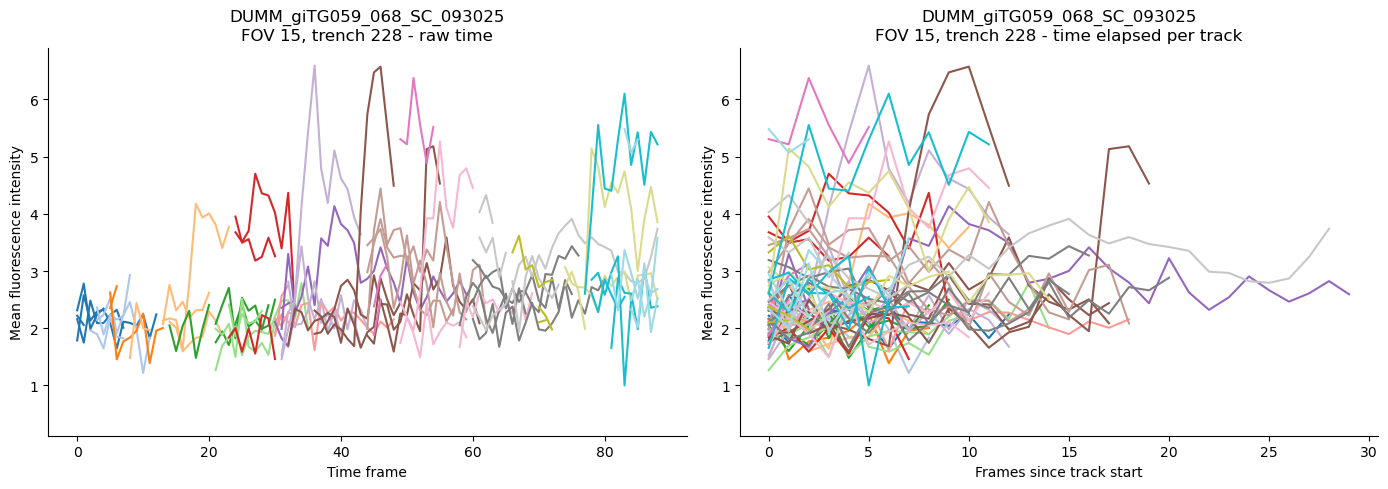

In [16]:
# example: fluorescence vs time for each unique cell track in one trench
# reuses the exp / fov / peak_id vars defined for the kymograph above
plot_track_fluorescence(all_data, exp, fov, peak_id)

# to focus on a single lineage, pass cell_id matching a track_id label from the kymograph:
# plot_track_fluorescence(all_data, exp, fov, peak_id, cell_id=1)


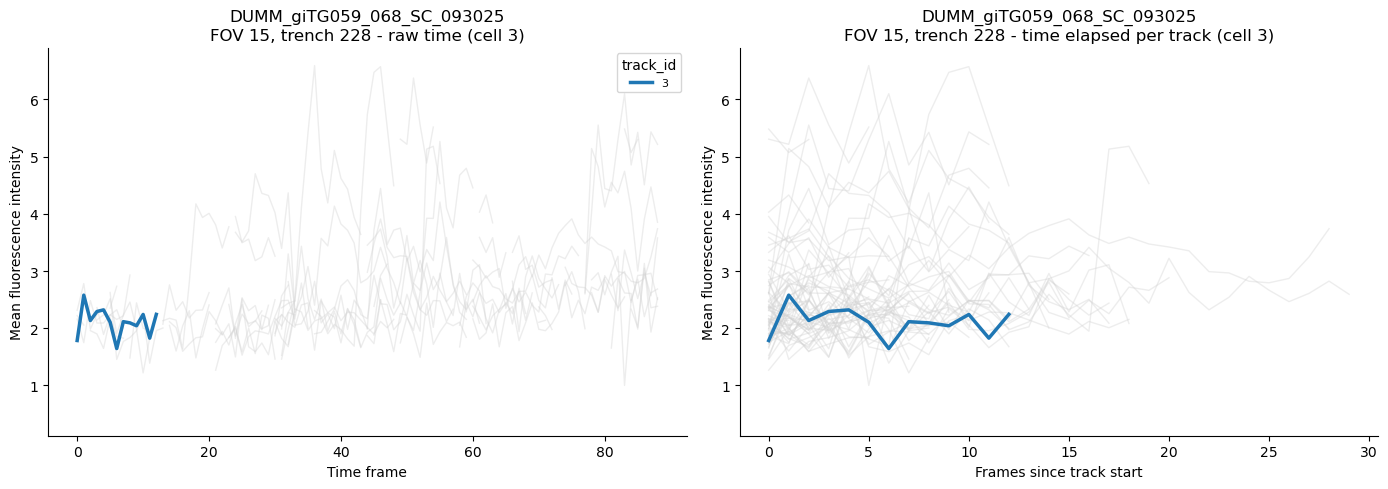

In [17]:
plot_track_fluorescence(all_data, exp, fov, peak_id, cell_id=3)

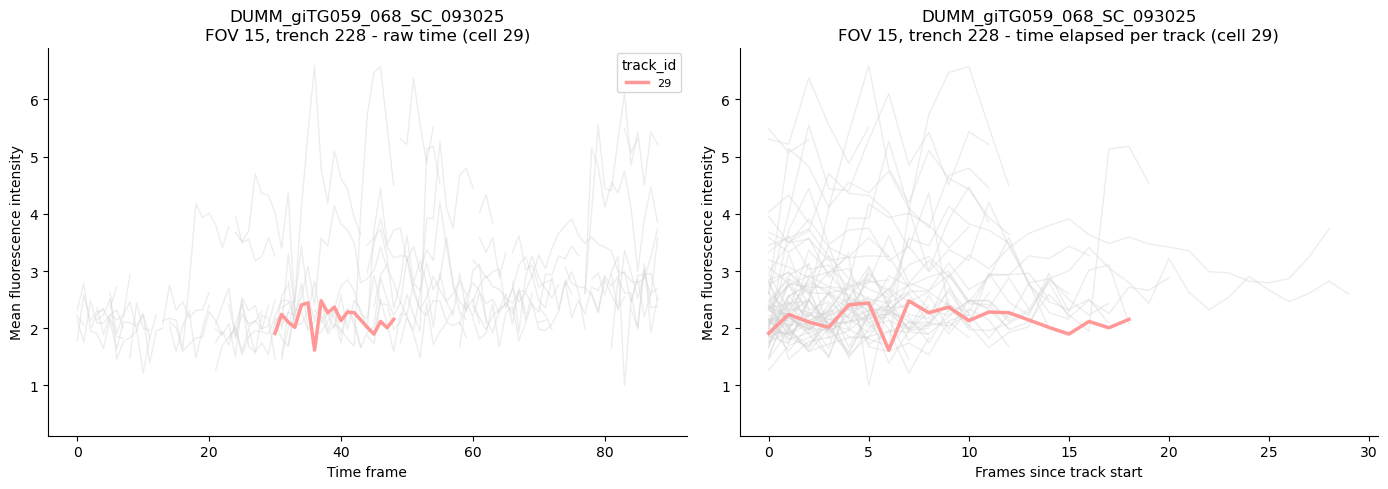

In [18]:
plot_track_fluorescence(all_data, exp, fov, peak_id, cell_id=29)


In [19]:
df_g = all_data.dropna(subset=['gene']).copy()

unmapped = sorted(set(all_data['experiment_name'].unique()) - set(df_g['experiment_name'].unique()))
if unmapped:
    print("WARNING: experiments with no gene mapping (excluded from per-gene stats):")
    for e in unmapped:
        print(f"  - {e}")

In [20]:
n_experiments_total = all_data['experiment_name'].nunique()

n_experiments = df_g.groupby('gene')['experiment_name'].nunique()
n_kymographs = df_g.groupby('gene').apply(
    lambda x: len(x[['experiment_name', 'FOV', 'trench_id']].drop_duplicates())
)
n_unique_cells = df_g.groupby('gene').apply(
    lambda x: len(x[['experiment_name', 'FOV', 'trench_id', 'track_id']].drop_duplicates())
)

summary = pd.DataFrame({
    'n_experiments': n_experiments,
    'n_kymographs': n_kymographs,
    'n_unique_cells': n_unique_cells,
}).sort_values('n_unique_cells', ascending=False)

print(f"Total experiments analyzed : {n_experiments_total}")
print(f"Total kymographs (peak_ids): {len(df_g[['experiment_name', 'FOV', 'trench_id']].drop_duplicates())}")
print(f"Total unique cells (tracks): {len(df_g[['experiment_name', 'FOV', 'trench_id', 'track_id']].drop_duplicates())}")
print("\nPer-gene summary:")
print(summary.to_string())

Total experiments analyzed : 18
Total kymographs (peak_ids): 235
Total unique cells (tracks): 10542

Per-gene summary:
      n_experiments  n_kymographs  n_unique_cells
gene                                             
baeS              3            53            2673
araB              2            36            1527
lacZ              3            23            1483
gfcE              4            29            1252
chpS              3            30            1250
alkA              4            22             802
gldA              3            19             781
mazF              3            13             521
murQ              1            10             253


/var/folders/z0/t_qxft797x97j_j_sdkjdv740000gn/T/ipykernel_72451/486162329.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  n_kymographs = df_g.groupby('gene').apply(
/var/folders/z0/t_qxft797x97j_j_sdkjdv740000gn/T/ipykernel_72451/486162329.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  n_unique_cells = df_g.groupby('gene').apply(


In [ ]:
df_bursts = detect_fluorescence_bursts_by_group(
    df_g,
    fluor_col='intensity_mean_fluor',
    rolling_window_size=10,
    std_dev_threshold=3,
)

bursts_per_gene = df_bursts.groupby('gene')['is_burst'].sum().sort_values(ascending=False)

constitutive_genes = {'mazF', 'hupA', 'chpS'}
``

In [22]:
# --- Cell-lineage tracked-duration summary ---
# A "cell lineage" = one track_id within a trench, keyed by (experiment, FOV, trench, track_id).
# Duration = elapsed span in minutes (last - first appearance), using the baked-in time_min column.

LINEAGE_KEYS = ['experiment_name', 'FOV', 'trench_id', 'track_id']


def lineage_durations(df):
    """One row per cell lineage with its tracked duration (elapsed span, minutes)."""
    g = df.groupby(LINEAGE_KEYS, observed=True).agg(
        gene=('gene', 'first'),
        t_min=('time_min', 'min'),
        t_max=('time_min', 'max'),
        n_frames=('time_frame', 'nunique'),
    ).reset_index()
    g['duration_min'] = g['t_max'] - g['t_min']
    return g


def summarize_lineage_duration(lin, group_by='gene'):
    """Average lineage duration, grouped flexibly by keyword: 'gene' or 'experiment'."""
    col = {'gene': 'gene', 'experiment': 'experiment_name'}[group_by]
    return (lin.groupby(col)['duration_min']
              .agg(mean_duration_min='mean', median_duration_min='median',
                   std_duration_min='std', n_lineages='count')
              .sort_values('mean_duration_min', ascending=False))


In [23]:
# compute per-lineage durations once, then summarize by each keyword
lin = lineage_durations(df_g)

by_gene = summarize_lineage_duration(lin, group_by='gene')
by_exp = summarize_lineage_duration(lin, group_by='experiment')

print(f"Total lineages: {len(lin)}  |  mean tracked duration: {lin['duration_min'].mean():.1f} min\n")
print("Average lineage duration by gene:")
print(by_gene.to_string())
print("\nAverage lineage duration by experiment:")
print(by_exp.to_string())


Total lineages: 10542  |  mean tracked duration: 54.7 min

Average lineage duration by gene:
      mean_duration_min  median_duration_min  std_duration_min  n_lineages
gene                                                                      
murQ          60.197628                 60.0         42.775258         253
lacZ          58.597438                 50.0         50.648844        1483
baeS          56.907969                 50.0         48.219687        2673
araB          55.638507                 50.0         50.475799        1527
chpS          53.680000                 50.0         51.542438        1250
gfcE          53.103035                 50.0         47.360124        1252
mazF          52.188100                 50.0         45.126011         521
alkA          48.503741                 40.0         48.234815         802
gldA          48.072983                 40.0         40.917754         781

Average lineage duration by experiment:
                                   mean_d

## Division-artifact–aware burst detection

Counts **bursts of expression** per gene / per experiment. Improves on `detect_fluorescence_bursts_by_group` (above), which mixed all trenches in a group, ignored cell division, and counted a single decaying burst many times.

Detection runs on the **per-trench max-fluorescence envelope** (`trench_max_envelope`) — the brightest cell at each frame. Because a burst is inherited by all descendants after a division, the max envelope traces the burst as one smooth hump and smooths away the per-cell cell-cycle sawtooth. A frame is a **burst** when it is:
1. **significantly above the gene × experiment baseline** — exceeds `median + k·(1.4826·MAD)` (robust modified z-score, so rare spikes don't inflate the baseline);
2. **the local peak** — the maximum within ±`window` frames on the envelope;
3. **a genuine rise** — prominence ≥ `k·mad_scale`. This is why flat-high **constitutive** genes (`mazF`, `hupA`, `chpS`) score ≈ 0 despite high absolute fluorescence.

**Division carryover** is handled by the max envelope: a daughter's inherited fluorescence is part of a decaying hump, never a fresh peak.

**One burst per decay (episode merge):** a burst that fades over many frames counts **once**. Walking candidate peaks in time, a later peak opens a *new* burst only if the envelope first **drops back below threshold** (resets to baseline, then re-rises) **or** climbs to a **genuinely higher new maximum** (> previous burst peak + prominence). A monotonic decay — nothing raises the maximum, nothing resets — stays a single burst.

Tunable: `k` (default 4), `window` (default ±5 frames), `min_prominence` (default `k·mad_scale`).


In [24]:
from scipy.signal import find_peaks


def build_lineage_traces(df_trench, fluor_col='intensity_mean_fluor'):
    """Stitch each cell onto its ancestors into continuous root->leaf fluorescence traces.

    A track_id only lasts until the cell divides (then daughters get new track_ids). Walking
    up parent_track_id and concatenating gives each root->leaf path as one continuous signal,
    so a daughter's *inherited* fluorescence appears as a declining slope rather than a fresh
    peak. Used here mainly for plotting the individual per-cell traces; burst detection runs
    on the per-frame max envelope (see detect_bursts / trench_max_envelope).

    Args:
        df_trench: rows for ONE (experiment_name, FOV, trench_id) group.
        fluor_col: fluorescence column to pull into the trace.

    Returns:
        list of DataFrames (one per root->leaf path), each sorted by time_frame with columns
        time_frame, fluor, node_id, track_id, predicted_lineage.
    """
    track_rows, parent_of, children = {}, {}, defaultdict(list)
    for tid, g in df_trench.groupby('track_id'):
        g = g.sort_values('time_frame')
        track_rows[tid] = g
        par = g['parent_track_id'].iloc[0]
        par = int(par) if pd.notna(par) else None
        parent_of[tid] = par
        if par is not None:
            children[par].append(tid)

    leaves = [t for t in track_rows if t not in children]
    if not leaves:                       # degenerate (e.g. a cycle) -> treat all as leaves
        leaves = list(track_rows)

    traces = []
    for leaf in leaves:
        chain, cur, seen = [], leaf, set()
        while cur is not None and cur in track_rows and cur not in seen:
            seen.add(cur)                # guard against cyclic parent references
            chain.append(cur)
            par = parent_of.get(cur)
            cur = par if (par in track_rows) else None
        chain.reverse()                  # root -> leaf order
        parts = [track_rows[t][['time_frame', fluor_col, 'node_id', 'track_id', 'predicted_lineage']]
                 for t in chain]
        trace = (pd.concat(parts).sort_values('time_frame').reset_index(drop=True)
                   .rename(columns={fluor_col: 'fluor'}))
        traces.append(trace)
    return traces


def trench_max_envelope(df_trench, fluor_col='intensity_mean_fluor'):
    """The brightest cell at each frame -> one continuous signal per trench.

    A burst is inherited by all descendants after a division, so at every frame the
    *maximum* fluorescence across the cells present captures the burst's envelope while
    smoothing the per-cell cell-cycle sawtooth. On this envelope a single burst that decays
    over many frames is one smooth hump, not many little peaks. Returns the picked rows
    (one per time_frame), sorted by time_frame.
    """
    idx = df_trench.groupby('time_frame')[fluor_col].idxmax()
    return df_trench.loc[idx].sort_values('time_frame').reset_index(drop=True)


def compute_baselines(df, fluor_col='intensity_mean_fluor'):
    """Robust per-(gene, experiment) baseline and MAD scale for a modified z-score.

    baseline = median fluorescence; scale = 1.4826 * MAD (median absolute deviation).
    Robust because rare bursts don't inflate the median/MAD (unlike mean/std). A small
    floor keeps the scale positive for near-constant (e.g. constitutive) signals so the
    threshold stays finite.

    Returns a DataFrame indexed by (gene, experiment_name) with columns median, mad_scale.
    """
    rows = []
    for (gene, exp), g in df.groupby(['gene', 'experiment_name']):
        x = g[fluor_col].to_numpy()
        med = np.median(x)
        mad = np.median(np.abs(x - med))
        rows.append({'gene': gene, 'experiment_name': exp,
                     'median': med, 'mad_scale': 1.4826 * mad})
    base = pd.DataFrame(rows).set_index(['gene', 'experiment_name'])
    base['mad_scale'] = base['mad_scale'].clip(lower=1e-6)
    return base


def detect_bursts(df, k=4.0, window=5, min_prominence=None,
                  fluor_col='intensity_mean_fluor', constitutive_genes=None):
    """Detect fluorescence bursts on the per-trench max-fluorescence envelope.

    For each (experiment, FOV, trench) the brightest cell at each frame forms one continuous
    signal (trench_max_envelope). Candidate peaks satisfy: (a) height > gene x experiment
    threshold median + k * mad_scale, (b) local maximum within +/- `window` frames, and
    (c) prominence >= min_prominence (a genuine rise). Prominence is why flat-high
    constitutive genes score ~0. Using the max envelope means a daughter's inherited
    fluorescence is part of a decaying hump, so division carryover is not miscounted.

    Episode merge (the key rule): a single burst that decays over many frames must count
    ONCE, not once per wobble on the way down. Walking candidate peaks in time, a later peak
    only opens a NEW burst when either the envelope first drops back below threshold (a reset
    to baseline, then re-rises) OR it climbs to a genuinely higher new maximum
    (> previous burst peak + min_prominence). Otherwise it is the same decaying/plateauing
    burst and is skipped.

    Args:
        df: per-cell-per-frame DataFrame (needs gene, experiment_name, FOV, trench_id,
            track_id, time_frame, node_id, predicted_lineage, fluor_col).
        k: robust z-score multiplier for the absolute height threshold.
        window: +/- frames for the local-maximum check and minimum peak separation.
        min_prominence: required rise; defaults to k * mad_scale (per gene x experiment).
        fluor_col: fluorescence column.
        constitutive_genes: optional set; only used to tag an 'is_constitutive' column.

    Returns:
        DataFrame with one row per burst event: experiment_name, FOV, trench_id, track_id,
        predicted_lineage, node_id, time_frame, fluor, gene, threshold, is_constitutive.
        (track_id / node_id / predicted_lineage identify the brightest cell at the peak.)
    """
    baselines = compute_baselines(df, fluor_col=fluor_col)
    constitutive_genes = constitutive_genes or set()
    records = []

    for (exp, fov, trench), df_trench in df.groupby(['experiment_name', 'FOV', 'trench_id']):
        gene = df_trench['gene'].iloc[0]
        if (gene, exp) not in baselines.index:
            continue
        med = baselines.loc[(gene, exp), 'median']
        scale = baselines.loc[(gene, exp), 'mad_scale']
        height = med + k * scale
        prom = k * scale if min_prominence is None else min_prominence

        env = trench_max_envelope(df_trench, fluor_col=fluor_col)
        sig = env[fluor_col].to_numpy()
        if len(sig) < 3:
            continue

        peaks, _ = find_peaks(sig, height=height, distance=window, prominence=prom)
        # explicit +/- window local-maximum check on the envelope
        cand = [pi for pi in peaks
                if sig[pi] >= sig[max(0, pi - window):min(len(sig), pi + window + 1)].max()]

        # episode merge: collapse a decaying burst to a single event
        cur_peak, last_i = -np.inf, None
        for pi in cand:
            if last_i is None:
                new = True
            elif sig[last_i:pi + 1].min() < height:      # returned to baseline -> reset
                new = True
            elif sig[pi] > cur_peak + prom:              # climbed to a higher new maximum
                new = True
            else:
                new = False                              # same decaying/plateauing burst
            if new:
                row = env.iloc[pi]
                records.append({
                    'experiment_name': exp, 'FOV': fov, 'trench_id': trench,
                    'track_id': int(row['track_id']), 'predicted_lineage': row['predicted_lineage'],
                    'node_id': int(row['node_id']), 'time_frame': int(row['time_frame']),
                    'fluor': float(row[fluor_col]), 'gene': gene, 'threshold': float(height),
                })
                cur_peak = sig[pi]
            last_i = pi

    cols = ['experiment_name', 'FOV', 'trench_id', 'track_id', 'predicted_lineage',
            'node_id', 'time_frame', 'fluor', 'gene', 'threshold', 'is_constitutive']
    if not records:
        return pd.DataFrame(columns=cols)
    bursts = pd.DataFrame(records)
    bursts['is_constitutive'] = bursts['gene'].isin(constitutive_genes)
    return bursts.reset_index(drop=True)


In [25]:
# --- run detection and report bursts per gene and per gene x experiment ---
bursts = detect_bursts(df_g, k=4.0, window=5, constitutive_genes=constitutive_genes)

# one row per lineage, for normalizing counts by sampling effort (defined earlier)
lin = lineage_durations(df_g)

# ---- per gene ----
n_bursts = bursts.groupby('gene').size().rename('n_bursts')
n_lineages = lin.groupby('gene').size().rename('n_lineages')
cell_hours = (lin.groupby('gene')['duration_min'].sum() / 60.0).rename('cell_hours')

gene_report = pd.concat([n_bursts, n_lineages, cell_hours], axis=1)
gene_report['n_bursts'] = gene_report['n_bursts'].fillna(0).astype(int)
gene_report['bursts_per_100_lineages'] = 100 * gene_report['n_bursts'] / gene_report['n_lineages']
gene_report['bursts_per_cell_hour'] = gene_report['n_bursts'] / gene_report['cell_hours']
gene_report['constitutive'] = gene_report.index.isin(constitutive_genes)
gene_report = gene_report.sort_values('bursts_per_100_lineages', ascending=False)

print(f"Total bursts detected: {len(bursts)}\n")
print("Bursts per gene (constitutive genes should be ~0):")
print(gene_report.to_string())

# ---- per gene x experiment ----
ge_counts = bursts.groupby(['gene', 'experiment_name']).size().rename('n_bursts')
ge_lineages = lin.groupby(['gene', 'experiment_name']).size().rename('n_lineages')
ge_report = pd.concat([ge_lineages, ge_counts], axis=1)
ge_report['n_bursts'] = ge_report['n_bursts'].fillna(0).astype(int)
ge_report['bursts_per_100_lineages'] = 100 * ge_report['n_bursts'] / ge_report['n_lineages']
ge_report = ge_report.reset_index().sort_values(['gene', 'experiment_name'])

print("\nBursts per gene x experiment:")
print(ge_report.to_string(index=False))


Total bursts detected: 75

Bursts per gene (constitutive genes should be ~0):
      n_bursts  n_lineages   cell_hours  bursts_per_100_lineages  bursts_per_cell_hour  constitutive
gene                                                                                                
lacZ        31        1483  1448.333333                 2.090357              0.021404         False
araB        19        1527  1416.000000                 1.244270              0.013418         False
gfcE        11        1252  1108.083333                 0.878594              0.009927         False
alkA         4         802   648.333333                 0.498753              0.006170         False
murQ         1         253   253.833333                 0.395257              0.003940         False
gldA         3         781   625.750000                 0.384123              0.004794         False
chpS         3        1250  1118.333333                 0.240000              0.002683          True
baeS         

In [26]:
def plot_bursts_for_trench(df, bursts, exp, fov, peak_id,
                           fluor_col='intensity_mean_fluor', k=4.0, window=5):
    """Overlay detected bursts on one trench (validation).

    Grey lines = the per-cell stitched lineage traces (build_lineage_traces). The orange
    line = the max-fluorescence envelope that detect_bursts actually runs on (brightest cell
    per frame). Red dots = detected bursts; dashed blue line = the gene x experiment
    threshold. A single decaying burst should get ONE red dot at its hump; a constitutive
    gene's steady-high envelope should get none.

    Args:
        df: per-cell-per-frame DataFrame (e.g. df_g).
        bursts: the burst-event DataFrame returned by detect_bursts.
        exp, fov, peak_id: which trench to plot (fov/peak_id accept str or int).
        fluor_col, k, window: kept consistent with the detect_bursts call.
    """
    fov = int(fov); peak_id = int(peak_id)
    df_trench = df[(df['experiment_name'] == exp) & (df['FOV'] == fov)
                   & (df['trench_id'] == peak_id)]
    if df_trench.empty:
        print(f"WARNING: no rows for {exp} FOV {fov} trench {peak_id}")
        return
    gene = df_trench['gene'].iloc[0]

    baselines = compute_baselines(df, fluor_col=fluor_col)
    height = None
    if (gene, exp) in baselines.index:
        b = baselines.loc[(gene, exp)]
        height = b['median'] + k * b['mad_scale']

    traces = build_lineage_traces(df_trench, fluor_col=fluor_col)
    env = trench_max_envelope(df_trench, fluor_col=fluor_col)
    b_tr = bursts[(bursts['experiment_name'] == exp) & (bursts['FOV'] == fov)
                  & (bursts['trench_id'] == peak_id)]

    fig, ax = plt.subplots(figsize=(11, 5))
    for trace in traces:
        ax.plot(trace['time_frame'], trace['fluor'],
                color='lightgray', lw=1, alpha=0.6, zorder=1)
    ax.plot(env['time_frame'], env[fluor_col],
            color='darkorange', lw=1.5, zorder=2, label='max envelope (detected on)')
    if not b_tr.empty:
        ax.scatter(b_tr['time_frame'], b_tr['fluor'],
                   color='crimson', s=70, zorder=4, label=f'burst (n={len(b_tr)})')
    if height is not None:
        ax.axhline(height, color='steelblue', ls='--', lw=1,
                   label=f'threshold = {height:.1f}')
    ax.set_xlabel('Time frame')
    ax.set_ylabel('Mean fluorescence intensity')
    ax.set_title(f'{gene}  |  {exp}\nFOV {fov}, trench {peak_id} - traces, max envelope & bursts')
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()


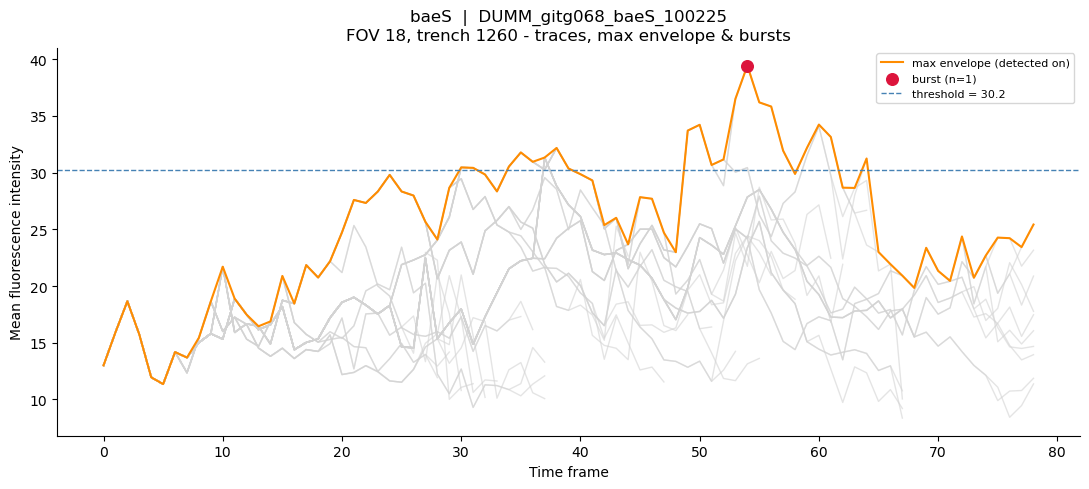

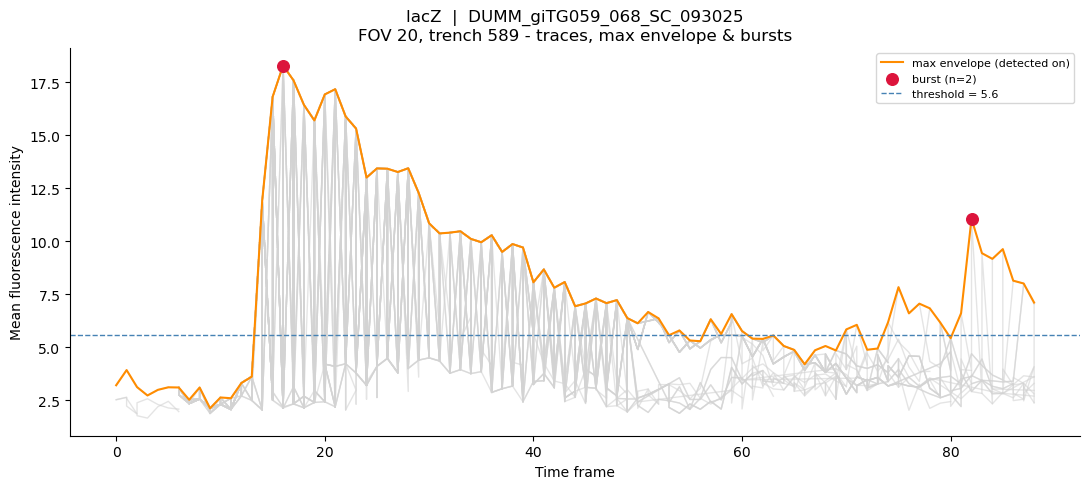

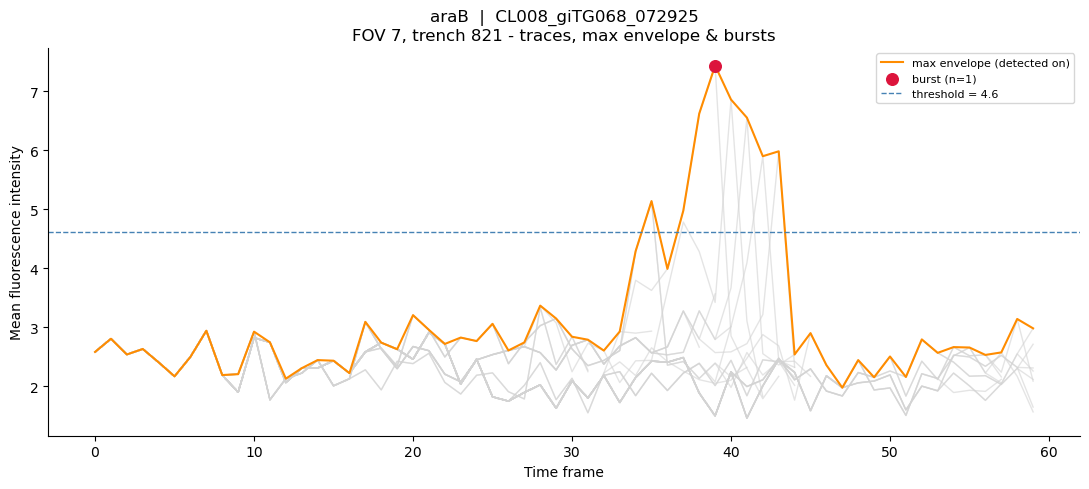

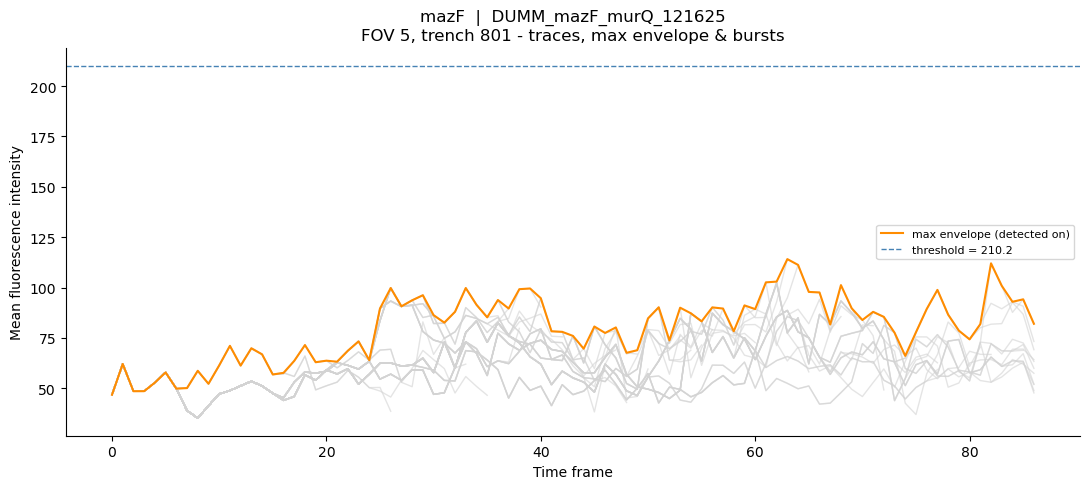

In [27]:
# example validation plots: overlay detected bursts on the stitched lineage traces.
# Pick known bursters and a constitutive gene to sanity-check the detector.

# baeS burster trench:
plot_bursts_for_trench(df_g, bursts, 'DUMM_gitg068_baeS_100225', 18, 1260)

# lacZ burster trench (many bursts):
plot_bursts_for_trench(df_g, bursts, 'DUMM_giTG059_068_SC_093025', 20, 589)

# araB burster trench:
plot_bursts_for_trench(df_g, bursts, 'CL008_giTG068_072925', 7, 821)

# constitutive gene (mazF) - expect ~no bursts despite high, steady fluorescence:
plot_bursts_for_trench(df_g, bursts, 'DUMM_mazF_murQ_121625', 5, 801)


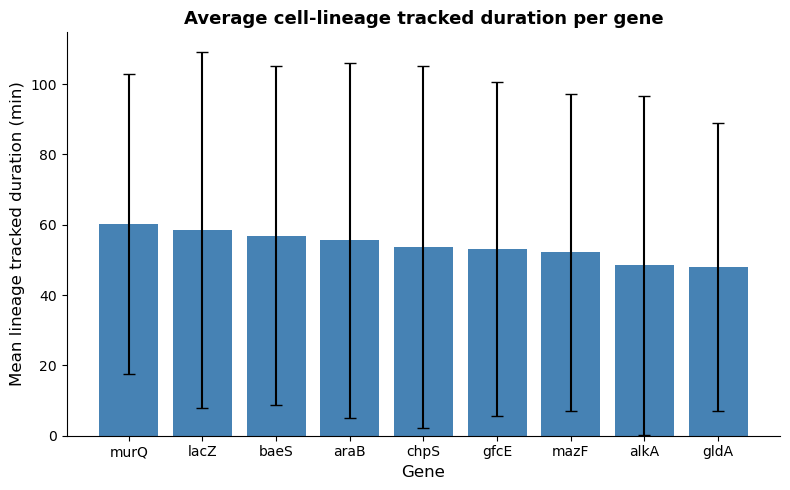

In [28]:
# mean lineage tracked-duration per gene (error bars = std across lineages)
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(by_gene.index, by_gene['mean_duration_min'],
       yerr=by_gene['std_duration_min'], capsize=4, color='steelblue')
ax.set_xlabel('Gene', fontsize=12)
ax.set_ylabel('Mean lineage tracked duration (min)', fontsize=12)
ax.set_title('Average cell-lineage tracked duration per gene', fontsize=13, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


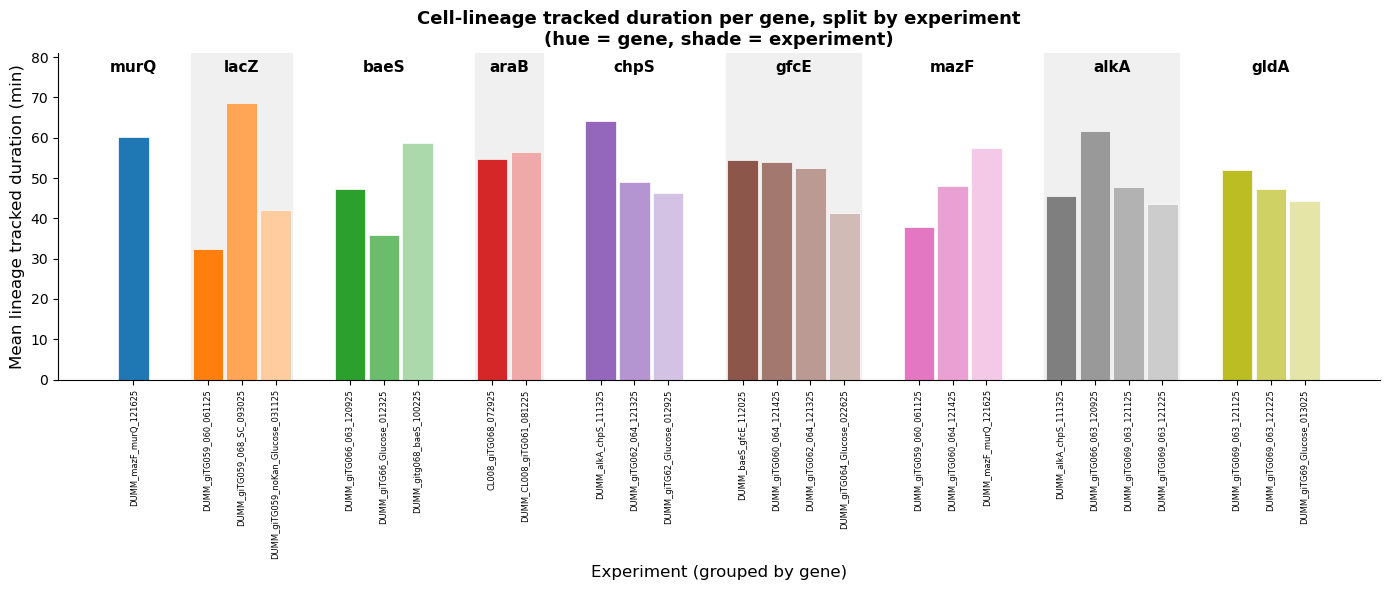

In [29]:
import matplotlib.colors as mcolors

# same data broken down by experiment within each gene, made clearer:
#   - bars are clustered per gene with a gap + alternating background so gene boundaries are obvious
#   - each gene has one base hue; its experiments are shades of that hue (consistent within a gene)
ge = (lin.groupby(['gene', 'experiment_name'])['duration_min']
         .mean().unstack('experiment_name'))
ge = ge.loc[by_gene.index]          # order genes by overall mean duration


def _shades(base, n):
    """n shades of a base color, from full strength toward lighter (blended with white)."""
    rgb = np.array(mcolors.to_rgb(base))
    factors = [0.0] if n == 1 else np.linspace(0.0, 0.6, n)
    return [tuple(rgb * (1 - f) + f) for f in factors]


base_cmap = plt.get_cmap('tab10')
fig, ax = plt.subplots(figsize=(14, 6))

x = 0.0
gap = 1.2
bar_w = 0.9
bar_ticks, bar_labels = [], []
gene_centers, cluster_spans = [], []

for gi, gene in enumerate(ge.index):
    row = ge.loc[gene].dropna().sort_index()          # experiments present for this gene
    colors = _shades(base_cmap(gi % 10), len(row))
    start = x
    for color, (exp_name, val) in zip(colors, row.items()):
        ax.bar(x, val, width=bar_w, color=color, edgecolor='white', linewidth=0.5)
        bar_ticks.append(x)
        bar_labels.append(exp_name)
        x += 1
    cluster_spans.append((start, x - 1))
    gene_centers.append(((start + x - 1) / 2, gene))
    x += gap

# alternating background bands to visually separate consecutive gene clusters
for gi, (start, end) in enumerate(cluster_spans):
    if gi % 2 == 1:
        ax.axvspan(start - 0.5, end + 0.5, color='0.94', zorder=0)

ymax = np.nanmax(ge.values) * 1.18
ax.set_ylim(0, ymax)

# bold gene label centered above each cluster
for center, gene in gene_centers:
    ax.text(center, ymax * 0.98, gene, ha='center', va='top',
            fontweight='bold', fontsize=11)

ax.set_xticks(bar_ticks)
ax.set_xticklabels(bar_labels, rotation=90, fontsize=6)
ax.set_xlabel('Experiment (grouped by gene)', fontsize=12)
ax.set_ylabel('Mean lineage tracked duration (min)', fontsize=12)
ax.set_title('Cell-lineage tracked duration per gene, split by experiment\n'
             '(hue = gene, shade = experiment)', fontsize=13, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()
